# 14: Heterogeneous Treatment Effects, GATE, CATE, and BLP

This lesson moves from the average treatment effect to effect heterogeneity: the idea that the same treatment can help different units by different amounts. In product analytics, policy analysis, experimentation, marketplace design, and recommender systems, this is usually where causal inference becomes operational. A single average effect can tell us whether a feature, treatment, or intervention is useful on average. It does not tell us where the value is concentrated, which users may be harmed, or which subgroup deserves a more careful rollout.

The DoubleML tools in this lesson are built around the same orthogonal-score logic used earlier in the tutorial series. We first estimate a valid global causal effect under standard identification assumptions. Then we use DoubleML's best linear predictor machinery to summarize heterogeneity in two related ways:

- **GATE**, or group average treatment effects, asks: what is the average effect inside each pre-defined group?
- **CATE**, or conditional average treatment effects, asks: how does the effect vary with observed covariates?
- **BLP**, or best linear predictor, is the practical bridge: it projects the estimated individual-level orthogonal signal onto a chosen set of features or basis functions. This does not magically recover every nonlinear individual effect. It gives a disciplined, uncertainty-aware summary of the effect pattern represented by the chosen basis.

The most important theme is humility. Heterogeneity analysis is easy to over-narrate. A subgroup with a high estimated effect is not automatically a deployable targeting rule. It may be noisy, it may depend on a modeling choice, and it is still only as credible as the causal identification design behind the original DoubleML model.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Heterogeneous Treatment Effects, GATE, CATE, And BLP**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the notebook separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment focuses on effect heterogeneity. The target is whether treatment works on average and where it works, but where and for whom it works. The experiment focuses on group-level and conditional heterogeneity. The grouping variables should be read as decision-relevant segments, not arbitrary labels.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

Heterogeneous treatment-effect analysis targets

$$
\tau(x)=\mathbb{E}\{Y(1)-Y(0)\mid X=x\}.
$$

A group average treatment effect is

$$
\tau_G=\mathbb{E}\{\tau(X)\mid X\in G\}.
$$

The examples estimate and summarize $\tau(x)$. Segment definitions, overlap, and multiplicity still matter for interpretation.





## Tutorial Workflow

#### Setup

This setup cell prepares the shared tutorial output folders, imports the libraries used throughout the notebook, and prints the DoubleML version. The code is intentionally visible because environment setup is part of a reproducible causal workflow.

A small note on warnings: the notebook suppresses common future/deprecation chatter and the familiar scikit-learn feature-name warning that can appear when estimators move between pandas and NumPy internally. It does not hide model failures or causal-design problems.

In [1]:
from pathlib import Path
import os
import warnings

# Find the repository root from wherever the notebook is executed.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "pyproject.toml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Set Matplotlib's cache before importing pyplot so notebook execution stays quiet.
os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error

import doubleml as dml
from doubleml import DoubleMLData, DoubleMLIRM

NOTEBOOK_PREFIX = "14"
RANDOM_SEED = 140

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"Project root: {PROJECT_ROOT}")
print(f"DoubleML version: {dml.__version__}")
print(f"Outputs will be written to: {OUTPUT_DIR}")


Project root: /home/apex/Documents/portfolio
DoubleML version: 0.11.2
Outputs will be written to: /home/apex/Documents/portfolio/notebooks/tutorials/doubleml/outputs


The setup confirms that the notebook is using the local environment and the shared DoubleML tutorial output folder. Every saved output in this lesson uses prefix `14`, so the files remain easy to connect back to this lesson.


#### Helper Functions

The helper functions below keep repeated code readable. The most important helper is `build_cate_basis()`: it defines the basis used for the CATE/BLP projection. In real work, this basis should be chosen before looking at a large number of subgroup results. Otherwise heterogeneity analysis can quietly turn into an exploratory search for whatever story looks strongest.

In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, filename):
    """
    Save a table in the tutorial output folder and return the unchanged DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    filename : object
        Filename used when saving a table, dataset, or figure artifact.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return df


def save_dataset(df, filename):
    """
    Save a dataset in the tutorial output folder and return the unchanged DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    filename : object
        Filename used when saving a table, dataset, or figure artifact.
    
    Returns
    -------
    pd.DataFrame
        Same dataset after writing it to the tutorial dataset directory.
    """
    path = DATASET_DIR / filename
    df.to_csv(path, index=False)
    return df


def sigmoid(values):
    """
    Numerically stable logistic transform for synthetic propensity scores.
    
    Parameters
    ----------
    values : array-like
        Numeric values transformed, standardized, summarized, or plotted by the helper.
    
    Returns
    -------
    np.ndarray
        Probability-scale values obtained by applying the logistic transform elementwise.
    """
    values = np.asarray(values)
    return 1.0 / (1.0 + np.exp(-values))


def rmse(y_true, y_pred):
    """
    Root mean squared error, used for outcome-nuisance diagnostics.
    
    Parameters
    ----------
    y_true : array-like
        Reference or oracle values used for evaluation.
    y_pred : array-like
        Predicted or estimated values being evaluated.
    
    Returns
    -------
    float
        Root mean squared error between the reference values and predictions.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def build_cate_basis(frame):
    """
    Construct the linear basis used by DoubleML's CATE/BLP method.
    
    Parameters
    ----------
    frame : pd.DataFrame
        DataFrame used by the helper.
    
    Returns
    -------
    pd.DataFrame
        CATE basis matrix used to project heterogeneous effects onto interpretable segment features.
    """
    return pd.DataFrame(
        {
            "intercept": 1.0,
            "engagement_z": frame["engagement_z"].to_numpy(),
            "price_sensitivity_z": frame["price_sensitivity_z"].to_numpy(),
            "high_engagement_flag": (frame["engagement_z"] > 0.5).astype(float).to_numpy(),
            "price_sensitive_flag": (frame["price_sensitivity_z"] > 0.5).astype(float).to_numpy(),
            "category_affinity_z": frame["category_affinity_z"].to_numpy(),
            "engagement_x_prior": (frame["engagement_z"] * frame["prior_value_z"]).to_numpy(),
        }
    )


def make_irm_data(frame, x_cols):
    """
    Create the DoubleMLData backend for a binary-treatment IRM example.
    
    Parameters
    ----------
    frame : pd.DataFrame
        DataFrame used by the helper.
    x_cols : list[str]
        Covariate column names used as model inputs.
    
    Returns
    -------
    DoubleMLData
        DoubleMLData object configured for binary-treatment IRM estimation.
    """
    return DoubleMLData(frame, y_col="outcome", d_cols="treatment", x_cols=x_cols)


def ci_error_columns(df, estimate_col="effect", lower_col="ci_lower", upper_col="ci_upper"):
    """
    Return asymmetric error-bar arrays for Matplotlib.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    estimate_col : str
        Column containing point estimates.
    lower_col : str
        Column containing lower confidence bounds.
    upper_col : str
        Column containing upper confidence bounds.
    
    Returns
    -------
    np.ndarray
        Two-row array of lower and upper error-bar lengths for interval plots.
    """
    return np.vstack(
        [
            df[estimate_col].to_numpy() - df[lower_col].to_numpy(),
            df[upper_col].to_numpy() - df[estimate_col].to_numpy(),
        ]
    )


These helpers encode two practical habits. First, every output is saved as a named output instead of only living in the notebook. Second, CATE summaries are tied to an explicit basis, which makes the heterogeneity claim auditable.


### Heterogeneity Vocabulary

Before fitting models, it helps to separate the estimands. These terms are often used loosely, but they answer different questions.

- **ATE** averages the treatment effect over the whole target population.
- **GATE** averages the treatment effect inside a group such as a tenure band, engagement segment, or risk tier.
- **CATE** conditions on covariates and is often written as `tau(x) = E[Y(1) - Y(0) | X = x]`.
- **BLP of CATE** is a linear projection of the CATE signal onto chosen basis features. It is a summary of heterogeneity, not a guarantee that the true effect is linear.
- **Effect modifier** is a covariate that changes the treatment effect itself, more than a covariate that predicts the outcome.

This table is saved because these definitions are useful language for a methods appendix or README.

| term | meaning | typical_question |
| --- | --- | --- |
| ATE | Average treatment effect across the target population. | Does the treatment help on average? |
| GATE | Group average treatment effect for mutually exclusive or deliberately defined groups. | Which pre-defined segment appears to benefit more? |
| CATE | Conditional average treatment effect as a function of observed covariates. | How does the effect vary with user or item features? |
| BLP | Best linear predictor of a heterogeneous effect signal using a chosen basis. | Which simple basis summarizes effect heterogeneity well? |
| Effect modifier | A variable that changes the treatment effect, more than the baseline outcome. | Does the causal effect itself change when this feature changes? |


The key distinction is between outcome prediction and effect modification. A feature can be highly predictive of `Y` while having no relationship to `Y(1) - Y(0)`. Heterogeneity analysis is about the second object.

### Synthetic Heterogeneous-Effect Design

We now create a synthetic binary-treatment dataset where the true treatment effect is known. The outcome is continuous, the treatment is assigned with confounding through observed covariates, and the treatment effect varies by engagement, price sensitivity, category affinity, and an engagement-by-prior-value interaction.

This is not meant to imitate a specific company or product. It is a teaching design that lets us compare DoubleML's estimated heterogeneity summaries against an oracle `true_tau` column. In real observational data, `true_tau` is never observed; it appears here only so the tutorial can show what the estimators are trying to recover.

In [3]:
rng = np.random.default_rng(RANDOM_SEED)
n_obs = 1_600

x_cols = [
    "engagement_z",
    "tenure_z",
    "price_sensitivity_z",
    "category_affinity_z",
    "prior_value_z",
    "support_load_z",
]

hte_df = pd.DataFrame(rng.normal(size=(n_obs, len(x_cols))), columns=x_cols)

# The treatment assignment is confounded: the same observed features affect both treatment and outcome.
propensity_logit = (
    -0.15
    + 0.55 * hte_df["engagement_z"]
    - 0.38 * hte_df["price_sensitivity_z"]
    + 0.25 * hte_df["prior_value_z"]
    - 0.22 * hte_df["support_load_z"]
    + 0.18 * hte_df["engagement_z"] * hte_df["category_affinity_z"]
)
hte_df["propensity_true"] = 0.08 + 0.84 * sigmoid(propensity_logit)
hte_df["treatment"] = rng.binomial(1, hte_df["propensity_true"])

# The true effect is deliberately heterogeneous and partly nonlinear.
hte_df["high_engagement_flag"] = (hte_df["engagement_z"] > 0.5).astype(int)
hte_df["price_sensitive_flag"] = (hte_df["price_sensitivity_z"] > 0.5).astype(int)
hte_df["true_tau"] = (
    0.45
    + 0.32 * hte_df["high_engagement_flag"]
    - 0.22 * hte_df["price_sensitive_flag"]
    + 0.16 * hte_df["category_affinity_z"]
    + 0.10 * hte_df["engagement_z"] * hte_df["prior_value_z"]
)

# This segment is mutually exclusive so it is valid for the GATE call below.
hte_df["segment"] = np.select(
    [hte_df["engagement_z"] > 0.7, hte_df["price_sensitivity_z"] > 0.7],
    ["high_engagement", "price_sensitive"],
    default="general",
)

baseline_outcome = (
    2.0
    + 0.60 * hte_df["engagement_z"]
    + 0.25 * hte_df["tenure_z"]
    - 0.45 * hte_df["support_load_z"]
    + 0.30 * hte_df["prior_value_z"]
    + 0.20 * np.sin(hte_df["category_affinity_z"])
)
hte_df["outcome"] = baseline_outcome + hte_df["true_tau"] * hte_df["treatment"] + rng.normal(0, 0.9, n_obs)

save_dataset(hte_df, f"{NOTEBOOK_PREFIX}_synthetic_hte_data.csv")
display(hte_df.head())


,engagement_z,tenure_z,price_sensitivity_z,category_affinity_z,prior_value_z,support_load_z,propensity_true,treatment,high_engagement_flag,price_sensitive_flag,true_tau,segment,outcome
0,-1.1761,1.7999,-1.1815,2.4726,-1.6690,0.4317,0.2484,1,0,0,1.0419,general,1.8086
1,-0.8547,-1.3900,-0.8436,-2.7860,1.1934,0.4980,0.5662,1,0,0,-0.0977,general,1.0207
2,-0.3210,-0.5196,1.6460,-1.6166,0.7760,-0.2077,0.3740,0,0,1,-0.0536,price_sensitive,3.0849
3,-0.1585,-0.0587,-0.4249,-0.6167,-0.1388,-1.3622,0.5433,0,0,0,0.3535,general,1.2246
4,0.7556,1.2016,1.8237,0.6995,0.2417,0.5579,0.4182,0,1,1,0.6802,high_engagement,0.8292


The first rows show the causal ingredients: observed controls, true treatment propensity, assigned treatment, true treatment effect, segment label, and observed outcome. The model will not use `true_tau` or `propensity_true`; those columns are retained only for diagnostics.

#### Field Dictionary

This field dictionary documents every column in the synthetic dataset. A clear data dictionary is especially useful for heterogeneity work because subgroup definitions can otherwise become ambiguous.

| column | role | description |
| --- | --- | --- |
| engagement_z | Observed control / effect modifier | Standardized prior engagement signal. |
| tenure_z | Observed control | Standardized account age or relationship length signal. |
| price_sensitivity_z | Observed control / effect modifier | Standardized signal for sensitivity to cost, friction, or effort. |
| category_affinity_z | Observed control / effect modifier | Standardized affinity for the treatment-relevant category. |
| prior_value_z | Observed control / interaction feature | Standardized prior value or historical outcome signal. |
| support_load_z | Observed control | Standardized friction, complaint, or support burden signal. |
| propensity_true | Oracle diagnostic | True treatment probability used by the simulator; not used by DoubleML. |
| treatment | Treatment | Binary treatment/exposure indicator. |
| high_engagement_flag | Effect-modifier basis feature | Indicator for engagement_z above 0.5. |
| price_sensitive_flag | Effect-modifier basis feature | Indicator for price_sensitivity_z above 0.5. |
| true_tau | Oracle diagnostic | True individual treatment effect from the simulator; unavailable in real data. |
| segment | GATE group | Mutually exclusive teaching segment used for group effect estimation. |
| outcome | Outcome | Observed continuous outcome after treatment assignment. |


The dictionary separates columns used for modeling from oracle-only columns. That separation matters: using `true_tau` or `propensity_true` in the learner would turn the tutorial into leakage rather than causal estimation.




## Diagnostics and Interpretation

### Basic Data Audit

The audit below checks sample size, treatment rate, propensity overlap, outcome scale, and the oracle average effect. These numbers are the first sanity check before any heterogeneity claim.

In [4]:
overall_audit = pd.DataFrame(
    [
        {"metric": "rows", "value": len(hte_df)},
        {"metric": "treatment_rate", "value": hte_df["treatment"].mean()},
        {"metric": "true_ate", "value": hte_df["true_tau"].mean()},
        {"metric": "outcome_mean", "value": hte_df["outcome"].mean()},
        {"metric": "outcome_std", "value": hte_df["outcome"].std()},
        {"metric": "min_true_propensity", "value": hte_df["propensity_true"].min()},
        {"metric": "max_true_propensity", "value": hte_df["propensity_true"].max()},
    ]
)

save_table(overall_audit, f"{NOTEBOOK_PREFIX}_overall_data_audit.csv")
display(overall_audit)


,metric,value
0,rows,1600.0000
1,treatment_rate,0.4769
2,true_ate,0.4801
3,outcome_mean,2.2282
4,outcome_std,1.3422
5,min_true_propensity,0.1033
6,max_true_propensity,0.8756


The treatment rate and propensity range indicate that the simulated design has overlap. Overlap is crucial: if a subgroup is almost always treated or almost never treated, its effect estimate becomes heavily model-dependent.

### Segment Audit

GATE estimation needs groups with enough observations and both treatment states represented. The code below summarizes the mutually exclusive teaching segments before asking DoubleML for group effects.

In [5]:
segment_audit = (
    hte_df.groupby("segment")
    .agg(
        n=("outcome", "size"),
        treatment_rate=("treatment", "mean"),
        outcome_mean=("outcome", "mean"),
        true_gate=("true_tau", "mean"),
        true_tau_std=("true_tau", "std"),
    )
    .reset_index()
    .sort_values("true_gate", ascending=False)
)

save_table(segment_audit, f"{NOTEBOOK_PREFIX}_segment_audit.csv")
display(segment_audit)


,segment,n,treatment_rate,outcome_mean,true_gate,true_tau_std
1,high_engagement,372,0.5806,3.2867,0.7252,0.2281
0,general,910,0.4813,1.9332,0.4592,0.2128
2,price_sensitive,318,0.3428,1.8342,0.2529,0.1962


The oracle column shows the pattern the estimator should recover: high-engagement users have larger effects, while price-sensitive users have smaller effects. In real data this column would be unavailable, so we would rely on design credibility, uncertainty, and validation checks.



### Teaching Design Diagram

The diagram below summarizes the causal structure used in this lesson. Observed controls affect treatment assignment and baseline outcomes. Some observed controls also modify the treatment effect. DoubleML estimates nuisance functions for treatment assignment and outcomes, then uses orthogonal scores to estimate causal effects and heterogeneity summaries.

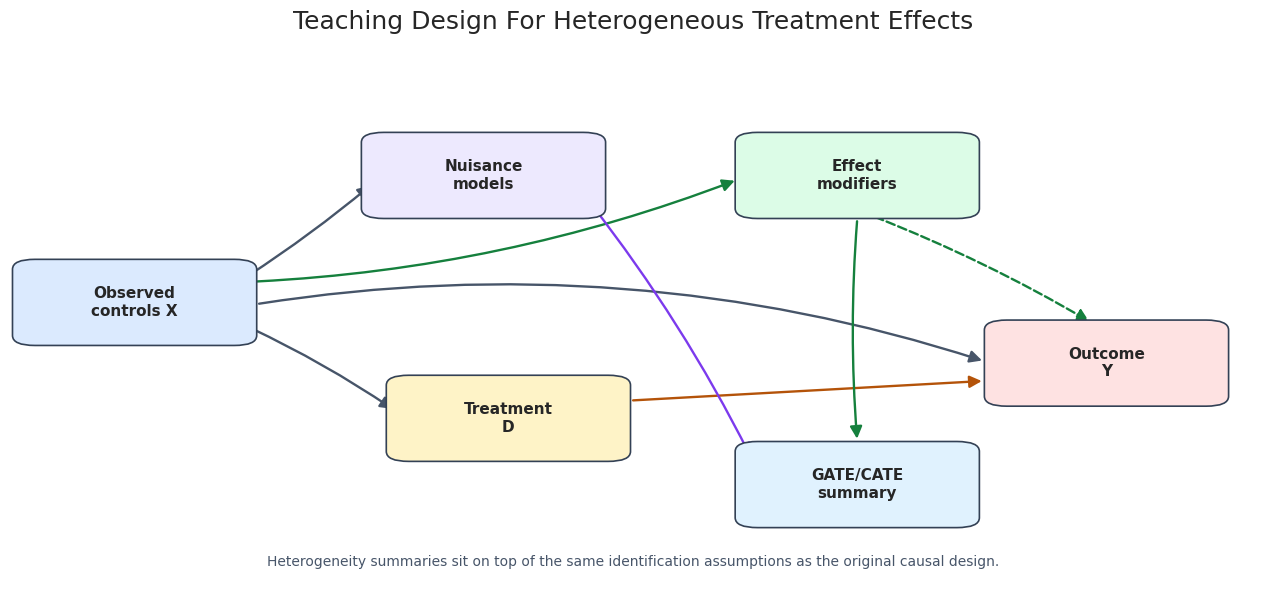

In [6]:
# Define reusable helpers for the Teaching Design Diagram section.
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_axis_off()

nodes = {
    "X": {"xy": (0.10, 0.55), "label": "Observed\ncontrols X", "color": "#dbeafe"},
    "N": {"xy": (0.38, 0.78), "label": "Nuisance\nmodels", "color": "#ede9fe"},
    "D": {"xy": (0.40, 0.34), "label": "Treatment\nD", "color": "#fef3c7"},
    "T": {"xy": (0.68, 0.78), "label": "Effect\nmodifiers", "color": "#dcfce7"},
    "Y": {"xy": (0.88, 0.44), "label": "Outcome\nY", "color": "#fee2e2"},
    "H": {"xy": (0.68, 0.22), "label": "GATE/CATE\nsummary", "color": "#e0f2fe"},
}

box_w, box_h = 0.16, 0.12


def anchor(node, side):
    """
    Idea: Return the plotting anchor point for a named node in the diagram.
    
    Parameters
    ----------
    node : object
        Graph node whose position, label, or incident edges are being processed.
    side : object
        Endpoint side used to place an arrow or edge on the correct part of a node.
    
    Returns
    -------
    tuple[float, float] or np.ndarray
        Coordinate of the requested side of a plotted node.
    """
    x, y = nodes[node]["xy"]
    offsets = {
        "left": (-box_w / 2, 0),
        "right": (box_w / 2, 0),
        "top": (0, box_h / 2),
        "bottom": (0, -box_h / 2),
        "upper_right": (box_w / 2, box_h * 0.25),
        "lower_right": (box_w / 2, -box_h * 0.25),
        "upper_left": (-box_w / 2, box_h * 0.25),
        "lower_left": (-box_w / 2, -box_h * 0.25),
    }
    dx, dy = offsets[side]
    return np.array([x + dx, y + dy], dtype=float)


def shorten(start, end, gap=0.018):
    """
    Idea: Shorten a line segment so the arrowhead remains visible outside the node box.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    tuple[float, float]
        Shortened endpoint coordinate that keeps an arrowhead visible.
    """
    start = np.asarray(start, dtype=float)
    end = np.asarray(end, dtype=float)
    delta = end - start
    length = np.hypot(delta[0], delta[1])
    if length == 0:
        return tuple(start), tuple(end)
    unit = delta / length
    return tuple(start + gap * unit), tuple(end - gap * unit)


def draw_arrow(start, end, color="#334155", style="solid", rad=0.0, linewidth=1.7):
    """
    Idea: Draw a routed arrow between diagram nodes while keeping the arrowhead visible.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    style : object
        Plotting style that determines how the curve, marker, or annotation is drawn.
    rad : float
        Curvature parameter for the plotted arrow.
    linewidth : object
        Line width used to make the plotted edge or reference line readable.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    start, end = shorten(start, end)
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        zorder=2,
    )
    ax.add_patch(arrow)

# Draw arrows before boxes so line endpoints tuck under the box borders cleanly.
draw_arrow(anchor("X", "upper_right"), anchor("N", "left"), color="#475569", rad=0.03)
draw_arrow(anchor("X", "lower_right"), anchor("D", "left"), color="#475569", rad=-0.04)
draw_arrow(anchor("X", "right"), anchor("Y", "left"), color="#475569", rad=-0.12)
draw_arrow(anchor("X", "upper_right"), anchor("T", "left"), color="#15803d", rad=0.08)
draw_arrow(anchor("D", "upper_right"), anchor("Y", "lower_left"), color="#b45309", rad=0.00)
draw_arrow(anchor("T", "bottom"), anchor("Y", "top"), color="#15803d", style="dashed", rad=-0.04)
draw_arrow(anchor("N", "lower_right"), anchor("H", "upper_left"), color="#7c3aed", rad=-0.05)
draw_arrow(anchor("T", "bottom"), anchor("H", "top"), color="#15803d", rad=0.04)

for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

ax.text(
    0.50,
    0.08,
    "Heterogeneity summaries sit on top of the same identification assumptions as the original causal design.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Teaching Design For Heterogeneous Treatment Effects", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_hte_teaching_design.png", dpi=160, bbox_inches="tight")
plt.show()


The dashed arrow from effect modifiers to the outcome represents effect modification: the causal effect of `D` changes with `X`. The GATE/CATE summary is downstream of the fitted orthogonal scores, not a separate identification strategy.

#### Fit the Baseline DoubleMLIRM Model

Because the treatment is binary and the outcome is continuous, this lesson uses `DoubleMLIRM`. The nuisance models are:

- `ml_g`: outcome regressions for the treated and untreated potential outcome surfaces.
- `ml_m`: the propensity model for treatment assignment.

The causal target here is the ATE. GATE and CATE/BLP summaries are then built from the fitted object.

In [7]:
# Fit or evaluate the model objects used in the Fit The Baseline DoubleMLIRM Model section.
np.random.seed(RANDOM_SEED)

# Random forests are stable, easy to explain, and avoid extra package-specific warnings.
ml_g = RandomForestRegressor(
    n_estimators=120,
    max_depth=7,
    min_samples_leaf=15,
    random_state=RANDOM_SEED + 1,
    n_jobs=-1,
)
ml_m = RandomForestClassifier(
    n_estimators=120,
    max_depth=6,
    min_samples_leaf=15,
    random_state=RANDOM_SEED + 2,
    n_jobs=-1,
)

dml_data = make_irm_data(hte_df, x_cols)
irm_model = DoubleMLIRM(
    dml_data,
    ml_g=clone(ml_g),
    ml_m=clone(ml_m),
    n_folds=5,
    n_rep=1,
    score="ATE",
)
irm_model.fit()

ate_table = pd.DataFrame(
    [
        {
            "estimand": "ATE",
            "estimate": float(irm_model.coef[0]),
            "std_error": float(irm_model.se[0]),
            "ci_95_lower": float(irm_model.confint().iloc[0, 0]),
            "ci_95_upper": float(irm_model.confint().iloc[0, 1]),
            "true_ate_in_simulation": float(hte_df["true_tau"].mean()),
        }
    ]
)

save_table(ate_table, f"{NOTEBOOK_PREFIX}_ate_estimate.csv")
display(ate_table)


,estimand,estimate,std_error,ci_95_lower,ci_95_upper,true_ate_in_simulation
0,ATE,0.5297,0.0499,0.4318,0.6276,0.4801


The ATE estimate is the anchor. If the global effect estimate were unstable or inconsistent with the design, it would be premature to tell subgroup stories. Here the estimate is close enough to the oracle average effect for the synthetic tutorial to proceed.



### Nuisance-Model Diagnostics

Heterogeneity summaries inherit the quality of the nuisance models. The next cell computes simple diagnostics from DoubleML's cross-fitted predictions: outcome RMSE for `ml_g0` and `ml_g1`, propensity log loss, propensity Brier score, and the estimated propensity range.

These are not causal diagnostics by themselves. They are checks that the machine-learning pieces are behaving sensibly before we use their orthogonal scores for causal summaries.

In [8]:
# Save the artifacts produced by the Nuisance-Model Diagnostics section.
pred_g0 = irm_model.predictions["ml_g0"][:, 0, 0]
pred_g1 = irm_model.predictions["ml_g1"][:, 0, 0]
pred_m = np.clip(irm_model.predictions["ml_m"][:, 0, 0], 1e-4, 1 - 1e-4)

mask_control = hte_df["treatment"].eq(0).to_numpy()
mask_treated = hte_df["treatment"].eq(1).to_numpy()

nuisance_diagnostics = pd.DataFrame(
    [
        {
            "diagnostic": "RMSE for untreated outcome model ml_g0",
            "value": rmse(hte_df.loc[mask_control, "outcome"], pred_g0[mask_control]),
        },
        {
            "diagnostic": "RMSE for treated outcome model ml_g1",
            "value": rmse(hte_df.loc[mask_treated, "outcome"], pred_g1[mask_treated]),
        },
        {
            "diagnostic": "Propensity log loss for ml_m",
            "value": float(log_loss(hte_df["treatment"], pred_m)),
        },
        {
            "diagnostic": "Propensity Brier score for ml_m",
            "value": float(brier_score_loss(hte_df["treatment"], pred_m)),
        },
        {"diagnostic": "Minimum estimated propensity", "value": float(pred_m.min())},
        {"diagnostic": "Maximum estimated propensity", "value": float(pred_m.max())},
    ]
)

save_table(nuisance_diagnostics, f"{NOTEBOOK_PREFIX}_nuisance_diagnostics.csv")
display(nuisance_diagnostics)


,diagnostic,value
0,RMSE for untreated outcome model ml_g0,0.9465
1,RMSE for treated outcome model ml_g1,0.9915
2,Propensity log loss for ml_m,0.6693
3,Propensity Brier score for ml_m,0.2383
4,Minimum estimated propensity,0.1933
5,Maximum estimated propensity,0.7960


The propensity scores stay away from zero and one, which supports the overlap needed for subgroup analysis. The outcome RMSE values are also reasonable relative to the noise scale used in the simulator.

#### Propensity Overlap Plot

A visual overlap check is often easier to read than a table. If treated and untreated units occupied disjoint regions of estimated propensity, subgroup estimates would lean heavily on extrapolation.

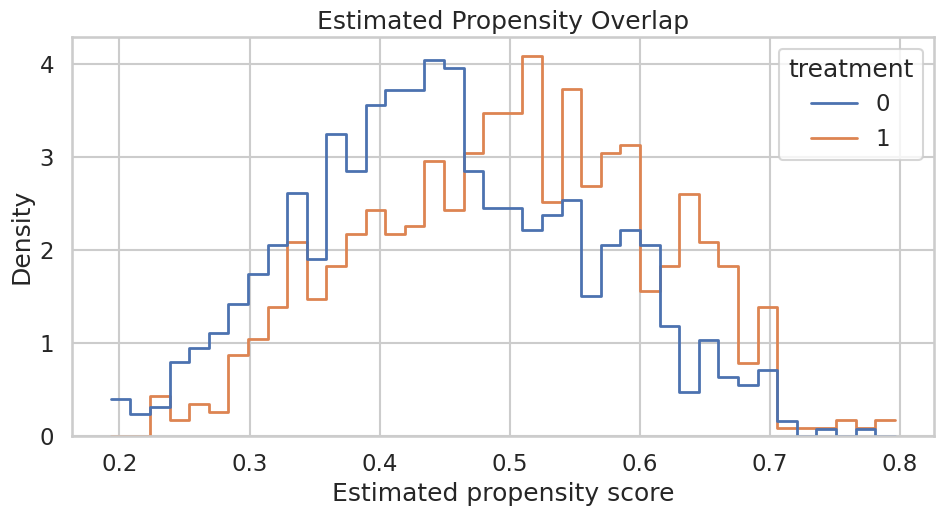

In [9]:
propensity_plot_df = hte_df.assign(estimated_propensity=pred_m)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(
    data=propensity_plot_df,
    x="estimated_propensity",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2,
    ax=ax,
)
ax.set_title("Estimated Propensity Overlap")
ax.set_xlabel("Estimated propensity score")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_estimated_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The two distributions overlap across most of the range. This avoids the most obvious positivity failure for the example. The causal design still needs the rest of the diagnostic checks.

### Oracle Effect Distribution

Before estimating heterogeneity, we look at the simulated `true_tau` distribution. This is a teaching luxury: it shows what kind of variation the GATE and CATE summaries are trying to compress.

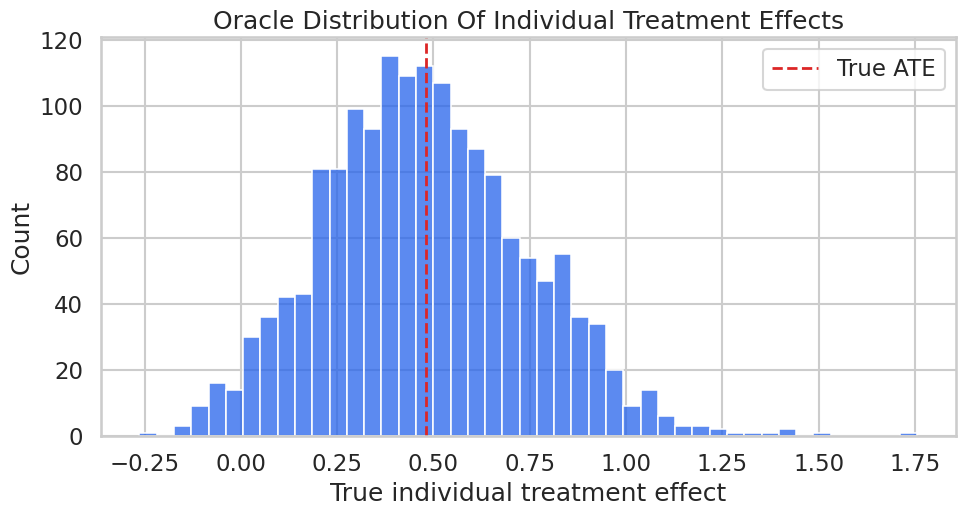

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(hte_df["true_tau"], bins=45, color="#2563eb", edgecolor="white", ax=ax)
ax.axvline(hte_df["true_tau"].mean(), color="#dc2626", linestyle="--", linewidth=2, label="True ATE")
ax.set_title("Oracle Distribution Of Individual Treatment Effects")
ax.set_xlabel("True individual treatment effect")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_oracle_true_tau_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The distribution is not a point mass, so an average effect hides real variation. The rest of the notebook asks how much of that variation can be summarized with groups and basis features.



#### Estimate GATEs with DoubleML

GATE estimation requires groups that are meaningful and sufficiently populated. The groups here are deliberately simple and mutually exclusive: `high_engagement`, `price_sensitive`, and `general`. DoubleML's `gate()` method returns a `DoubleMLBLP` object, which provides coefficient summaries and confidence intervals.

In [11]:
gate_groups = pd.DataFrame({"segment": hte_df["segment"]})
gate_model = irm_model.gate(gate_groups)

np.random.seed(RANDOM_SEED)
gate_ci = gate_model.confint(joint=True, level=0.95, n_rep_boot=300).reset_index()
gate_ci = gate_ci.rename(
    columns={
        "index": "gate_label",
        "2.5 %": "ci_lower",
        "97.5 %": "ci_upper",
        "effect": "effect",
    }
)
gate_ci["segment"] = gate_ci["gate_label"].str.replace("Group_", "", regex=False)

gate_true = (
    hte_df.groupby("segment")
    .agg(n=("outcome", "size"), treatment_rate=("treatment", "mean"), true_gate=("true_tau", "mean"))
    .reset_index()
)

gate_results = gate_ci.merge(gate_true, on="segment", how="left")
gate_results = gate_results.sort_values("effect", ascending=False)

save_table(gate_model.summary.reset_index().rename(columns={"index": "gate_label"}), f"{NOTEBOOK_PREFIX}_gate_summary.csv")
save_table(gate_results, f"{NOTEBOOK_PREFIX}_gate_results_with_oracle.csv")
display(gate_results)


,gate_label,ci_lower,effect,ci_upper,segment,n,treatment_rate,true_gate
1,Group_high_engagement,0.3878,0.7856,1.1834,high_engagement,372,0.5806,0.7252
0,Group_general,0.2838,0.5513,0.8189,general,910,0.4813,0.4592
2,Group_price_sensitive,-0.2843,0.1684,0.6211,price_sensitive,318,0.3428,0.2529


The estimated group ranking follows the synthetic design: the high-engagement group benefits most, while the price-sensitive group has the smallest effect. Notice that the confidence intervals still matter; GATE estimates are summaries with uncertainty, not labels permanently attached to users.

#### Plot Estimated GATEs Against Oracle Group Effects

This plot compares estimated group effects with the oracle group means. In real data, the blue oracle markers would be absent; they are included here only to make the tutorial measurable.

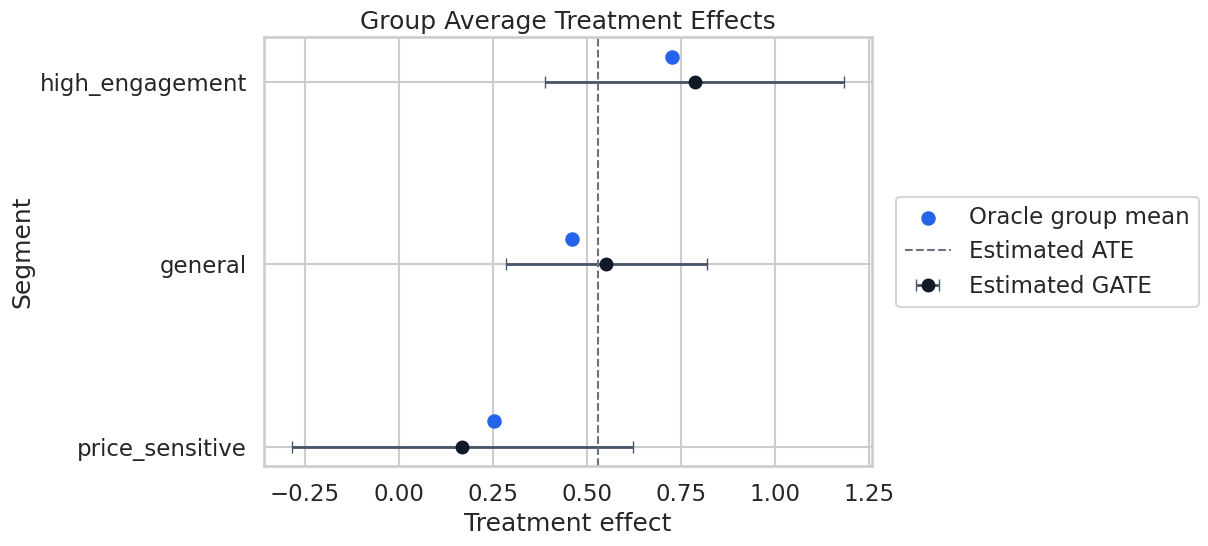

In [12]:
# Build and label the diagnostic visualization for the Plot Estimated GATEs Against Oracle Group Effects section.
plot_gate = gate_results.sort_values("effect")
y_positions = np.arange(len(plot_gate))

fig, ax = plt.subplots(figsize=(12.5, 5.8))
ax.errorbar(
    x=plot_gate["effect"],
    y=y_positions,
    xerr=ci_error_columns(plot_gate),
    fmt="o",
    color="#111827",
    ecolor="#475569",
    elinewidth=2,
    capsize=4,
    label="Estimated GATE",
)
ax.scatter(plot_gate["true_gate"], y_positions + 0.14, color="#2563eb", s=80, label="Oracle group mean")
ax.axvline(float(irm_model.coef[0]), color="#6b7280", linestyle="--", linewidth=1.5, label="Estimated ATE")
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_gate["segment"])
ax.set_title("Group Average Treatment Effects")
ax.set_xlabel("Treatment effect")
ax.set_ylabel("Segment")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_gate_estimates.png", dpi=160, bbox_inches="tight")
plt.show()


The plot makes the reporting task clearer than a table alone. The high-engagement segment is above the ATE, the price-sensitive segment is below it, and the uncertainty bars show how much precision we actually have.

### CATE as a Best Linear Predictor

DoubleML's `cate()` method estimates a best linear predictor of the heterogeneous treatment effect signal on a basis supplied by the analyst. This is why basis design is not a cosmetic choice. The basis defines the heterogeneity language the model is allowed to speak.

The basis below includes continuous terms, threshold indicators, and one interaction. It is intentionally close to the synthetic data-generating process, but not identical enough to be trivial.

In [13]:
cate_basis = build_cate_basis(hte_df)
cate_blp = irm_model.cate(cate_basis)

cate_summary = cate_blp.summary.reset_index().rename(columns={"index": "basis_feature"})
save_table(cate_summary, f"{NOTEBOOK_PREFIX}_cate_blp_summary.csv")
display(cate_summary)

,basis_feature,coef,std err,t,P>|t|,[0.025,0.975]
0,intercept,0.5805,0.0862,6.7333,0.0000,0.4116,0.7495
1,engagement_z,0.0153,0.0849,0.1800,0.8571,-0.1511,0.1816
2,price_sensitivity_z,0.0003,0.0794,0.0043,0.9966,-0.1553,0.1559
3,high_engagement_flag,0.2226,0.1742,1.2777,0.2013,-0.1189,0.5642
4,price_sensitive_flag,-0.3812,0.1647,-2.3142,0.0207,-0.7040,-0.0583
5,category_affinity_z,0.1706,0.0486,3.5123,0.0004,0.0754,0.2658
6,engagement_x_prior,0.0909,0.0506,1.7968,0.0724,-0.0083,0.1900


The coefficient signs line up with the simulator: high engagement is associated with larger treatment effects, price sensitivity is associated with smaller treatment effects, and category affinity contributes positively. The coefficient table should be read as a projection summary, not as proof that the true CATE is exactly linear.

#### Plot the BLP Coefficients

The coefficient plot is a compact way to communicate which basis features are associated with heterogeneity. We exclude the intercept so the plot focuses on variation around the average.

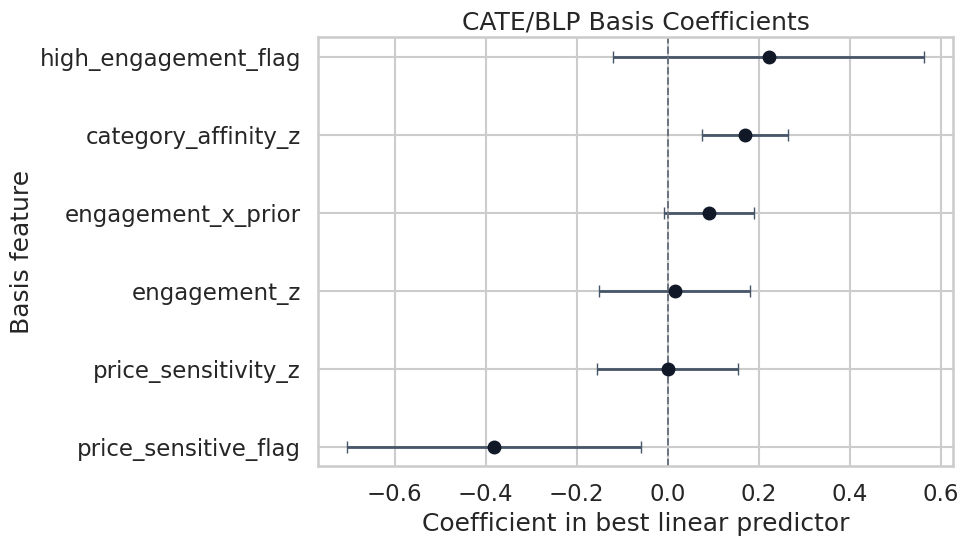

In [14]:
# Build and label the diagnostic visualization for the Plot The BLP Coefficients section.
coef_plot_df = cate_summary.query("basis_feature != 'intercept'").copy()
coef_plot_df = coef_plot_df.rename(columns={"[0.025": "ci_lower", "0.975]": "ci_upper"})
coef_plot_df = coef_plot_df.sort_values("coef")

fig, ax = plt.subplots(figsize=(10, 5.8))
ax.errorbar(
    x=coef_plot_df["coef"],
    y=np.arange(len(coef_plot_df)),
    xerr=np.vstack([
        coef_plot_df["coef"] - coef_plot_df["ci_lower"],
        coef_plot_df["ci_upper"] - coef_plot_df["coef"],
    ]),
    fmt="o",
    color="#111827",
    ecolor="#475569",
    elinewidth=2,
    capsize=4,
)
ax.axvline(0, color="#6b7280", linestyle="--", linewidth=1.4)
ax.set_yticks(np.arange(len(coef_plot_df)))
ax.set_yticklabels(coef_plot_df["basis_feature"])
ax.set_title("CATE/BLP Basis Coefficients")
ax.set_xlabel("Coefficient in best linear predictor")
ax.set_ylabel("Basis feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cate_blp_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()


The coefficient plot is useful for screening patterns, but it should not replace substantive judgment. If the basis features were chosen after many failed attempts, the uncertainty shown here would understate the total search process.

#### CATE Profile Over Engagement

A BLP can also be evaluated on a grid of profiles. Here we vary engagement while holding price sensitivity and category affinity at zero and prior value at `0.8`. This creates a simple curve showing how the fitted heterogeneity summary changes with engagement.

In [15]:
profile_grid = pd.DataFrame(
    {
        "engagement_z": np.linspace(-2.0, 2.0, 41),
        "tenure_z": 0.0,
        "price_sensitivity_z": 0.0,
        "category_affinity_z": 0.0,
        "prior_value_z": 0.8,
        "support_load_z": 0.0,
    }
)
profile_basis = build_cate_basis(profile_grid)

np.random.seed(RANDOM_SEED)
profile_ci = cate_blp.confint(basis=profile_basis, joint=True, level=0.95, n_rep_boot=300).reset_index(drop=True)
profile_results = pd.concat([profile_grid[["engagement_z", "prior_value_z"]], profile_ci], axis=1)
profile_results = profile_results.rename(columns={"2.5 %": "ci_lower", "97.5 %": "ci_upper"})
profile_results["oracle_tau_profile"] = (
    0.45
    + 0.32 * (profile_results["engagement_z"] > 0.5).astype(float)
    + 0.10 * profile_results["engagement_z"] * profile_results["prior_value_z"]
)

save_table(profile_results, f"{NOTEBOOK_PREFIX}_cate_engagement_profile.csv")
display(profile_results.head(10))


,engagement_z,prior_value_z,ci_lower,effect,ci_upper,oracle_tau_profile
0,-2.0000,0.8000,-0.1941,0.4046,1.0033,0.2900
1,-1.9000,0.8000,-0.1553,0.4134,0.9821,0.2980
2,-1.8000,0.8000,-0.1169,0.4222,0.9613,0.3060
3,-1.7000,0.8000,-0.0791,0.4310,0.9410,0.3140
4,-1.6000,0.8000,-0.0418,0.4398,0.9213,0.3220
5,-1.5000,0.8000,-0.0052,0.4486,0.9023,0.3300
6,-1.4000,0.8000,0.0305,0.4574,0.8842,0.3380
7,-1.3000,0.8000,0.0653,0.4662,0.8670,0.3460
8,-1.2000,0.8000,0.0988,0.4750,0.8511,0.3540
9,-1.1000,0.8000,0.1308,0.4838,0.8367,0.3620


The profile table turns the CATE/BLP object into predicted effects for concrete covariate profiles. This is often easier for stakeholders to understand than a coefficient table, as long as we make clear that the curve is model-based.

#### Plot the CATE Profile

The confidence band below is a joint band from the BLP object. Joint bands are wider than pointwise intervals because they account for looking across the whole profile grid.

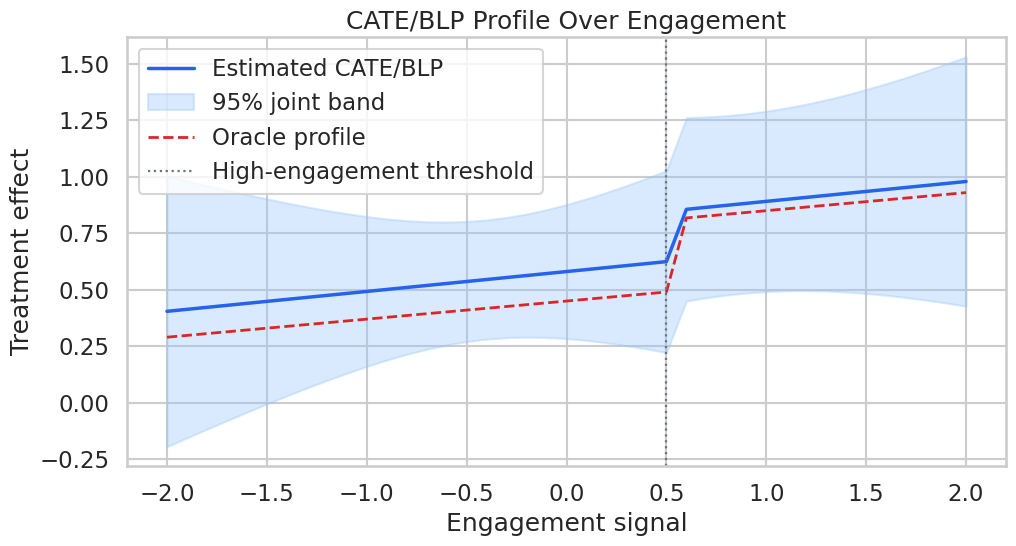

In [16]:
# Build and label the diagnostic visualization for the Plot The CATE Profile section.
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(profile_results["engagement_z"], profile_results["effect"], color="#2563eb", linewidth=2.5, label="Estimated CATE/BLP")
ax.fill_between(
    profile_results["engagement_z"],
    profile_results["ci_lower"],
    profile_results["ci_upper"],
    color="#93c5fd",
    alpha=0.35,
    label="95% joint band",
)
ax.plot(
    profile_results["engagement_z"],
    profile_results["oracle_tau_profile"],
    color="#dc2626",
    linestyle="--",
    linewidth=2,
    label="Oracle profile",
)
ax.axvline(0.5, color="#6b7280", linestyle=":", linewidth=1.6, label="High-engagement threshold")
ax.set_title("CATE/BLP Profile Over Engagement")
ax.set_xlabel("Engagement signal")
ax.set_ylabel("Treatment effect")
ax.legend(loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cate_engagement_profile.png", dpi=160, bbox_inches="tight")
plt.show()


The estimated profile captures the main upward shift after the high-engagement threshold, though the band reminds us that profile-level heterogeneity is less precise than the global ATE.



#### CATE Profile Over Price Sensitivity

The previous profile varied a positive modifier. This profile varies price sensitivity, which the simulator makes a negative effect modifier. Looking at both directions helps prevent a one-sided heterogeneity story.

In [17]:
price_grid = pd.DataFrame(
    {
        "engagement_z": 0.0,
        "tenure_z": 0.0,
        "price_sensitivity_z": np.linspace(-2.0, 2.0, 41),
        "category_affinity_z": 0.0,
        "prior_value_z": 0.0,
        "support_load_z": 0.0,
    }
)
price_basis = build_cate_basis(price_grid)
price_ci = cate_blp.confint(basis=price_basis, joint=True, level=0.95, n_rep_boot=300).reset_index(drop=True)
price_results = pd.concat([price_grid[["price_sensitivity_z"]], price_ci], axis=1)
price_results = price_results.rename(columns={"2.5 %": "ci_lower", "97.5 %": "ci_upper"})
price_results["oracle_tau_profile"] = 0.45 - 0.22 * (price_results["price_sensitivity_z"] > 0.5).astype(float)

save_table(price_results, f"{NOTEBOOK_PREFIX}_cate_price_sensitivity_profile.csv")
display(price_results.head(10))


,price_sensitivity_z,ci_lower,effect,ci_upper,oracle_tau_profile
0,-2.0000,-0.1001,0.5799,1.2599,0.4500
1,-1.9000,-0.0695,0.5799,1.2293,0.4500
2,-1.8000,-0.0396,0.5799,1.1994,0.4500
3,-1.7000,-0.0104,0.5800,1.1703,0.4500
4,-1.6000,0.0180,0.5800,1.1420,0.4500
5,-1.5000,0.0453,0.5800,1.1148,0.4500
6,-1.4000,0.0715,0.5801,1.0887,0.4500
7,-1.3000,0.0963,0.5801,1.0639,0.4500
8,-1.2000,0.1195,0.5801,1.0407,0.4500
9,-1.1000,0.1409,0.5802,1.0194,0.4500


The profile table shows the estimated effect declining as price sensitivity rises. The sharp oracle drop appears at the threshold because the synthetic data-generating process included a threshold indicator.

#### Plot the Price-Sensitivity Profile

This plot is a useful contrast with the engagement profile: one modifier increases treatment value, while another reduces it.

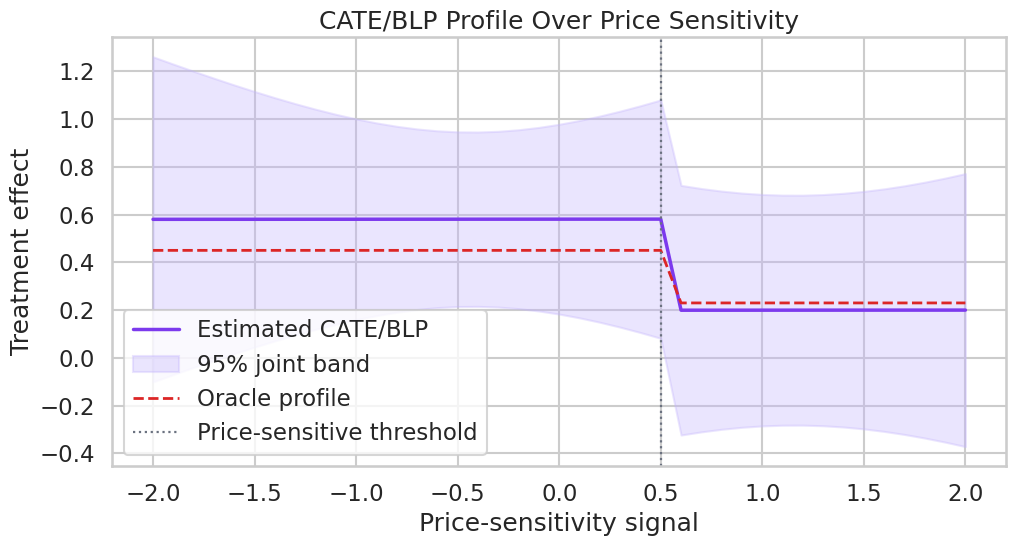

In [18]:
# Build and label the diagnostic visualization for the Plot The Price-Sensitivity Profile section.
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(price_results["price_sensitivity_z"], price_results["effect"], color="#7c3aed", linewidth=2.5, label="Estimated CATE/BLP")
ax.fill_between(
    price_results["price_sensitivity_z"],
    price_results["ci_lower"],
    price_results["ci_upper"],
    color="#c4b5fd",
    alpha=0.35,
    label="95% joint band",
)
ax.plot(
    price_results["price_sensitivity_z"],
    price_results["oracle_tau_profile"],
    color="#dc2626",
    linestyle="--",
    linewidth=2,
    label="Oracle profile",
)
ax.axvline(0.5, color="#6b7280", linestyle=":", linewidth=1.6, label="Price-sensitive threshold")
ax.set_title("CATE/BLP Profile Over Price Sensitivity")
ax.set_xlabel("Price-sensitivity signal")
ax.set_ylabel("Treatment effect")
ax.legend(loc="lower left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cate_price_sensitivity_profile.png", dpi=160, bbox_inches="tight")
plt.show()


This pattern is exactly the kind of result that needs careful translation. A lower estimated effect for a subgroup does not automatically mean the subgroup should be excluded; it means the treatment may need a different design, message, cost, or eligibility rule.



#### A Cautionary Subgroup Drill

Subgroup analysis is vulnerable to over-searching. To make that concrete, the next cell estimates GATEs for tenure terciles. In the simulator, tenure affects baseline outcomes but is not a direct effect modifier. If we still see variation, that variation is a reminder that subgroup estimates can move around even when the causal effect is not designed to differ much by that grouping.

In [19]:
tenure_groups = pd.DataFrame(
    {
        "tenure_group": pd.qcut(
            hte_df["tenure_z"],
            q=3,
            labels=["low_tenure", "mid_tenure", "high_tenure"],
        ).astype(str)
    }
)

tenure_gate_model = irm_model.gate(tenure_groups)
tenure_gate_ci = tenure_gate_model.confint(joint=True, level=0.95, n_rep_boot=300).reset_index()
tenure_gate_ci = tenure_gate_ci.rename(
    columns={"index": "gate_label", "2.5 %": "ci_lower", "97.5 %": "ci_upper"}
)
tenure_gate_ci["tenure_group"] = tenure_gate_ci["gate_label"].str.replace("Group_", "", regex=False)

tenure_true = (
    hte_df.assign(tenure_group=tenure_groups["tenure_group"])
    .groupby("tenure_group")
    .agg(n=("outcome", "size"), true_gate=("true_tau", "mean"), treatment_rate=("treatment", "mean"))
    .reset_index()
)
tenure_gate_results = tenure_gate_ci.merge(tenure_true, on="tenure_group", how="left")

save_table(tenure_gate_results, f"{NOTEBOOK_PREFIX}_tenure_gate_caution.csv")
display(tenure_gate_results)


,gate_label,ci_lower,effect,ci_upper,tenure_group,n,true_gate,treatment_rate
0,Group_high_tenure,0.2657,0.5298,0.7938,high_tenure,533,0.4896,0.4784
1,Group_low_tenure,0.3160,0.5768,0.8376,low_tenure,534,0.4748,0.4644
2,Group_mid_tenure,0.2373,0.4824,0.7276,mid_tenure,533,0.4758,0.4878


The tenure groups have estimated differences, but the oracle group effects are much closer together than the main engagement and price-sensitive segments. This is why subgroup analysis should start with theory and pre-specified segmentation, not a search over every available column.

#### Plot the Cautionary Tenure GATEs

The tenure plot is deliberately included as a counterweight to the more convincing segment analysis above. Strong causal notebooks should show what *not* to overstate.

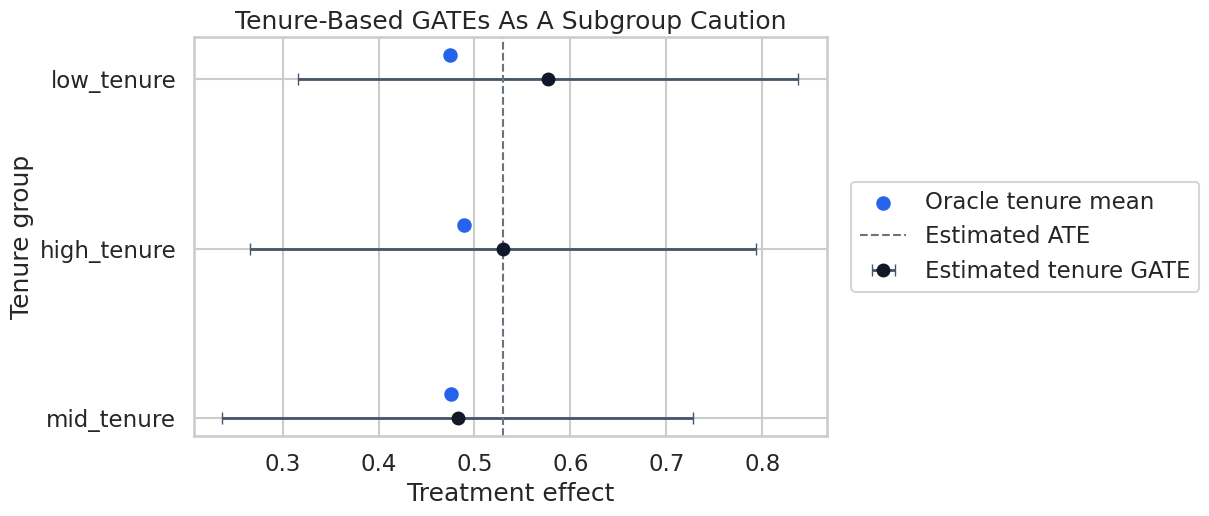

In [20]:
# Build and label the diagnostic visualization for the Plot The Cautionary Tenure GATEs section.
plot_tenure = tenure_gate_results.sort_values("effect")
y_positions = np.arange(len(plot_tenure))

fig, ax = plt.subplots(figsize=(12.5, 5.5))
ax.errorbar(
    x=plot_tenure["effect"],
    y=y_positions,
    xerr=ci_error_columns(plot_tenure),
    fmt="o",
    color="#111827",
    ecolor="#475569",
    elinewidth=2,
    capsize=4,
    label="Estimated tenure GATE",
)
ax.scatter(plot_tenure["true_gate"], y_positions + 0.14, color="#2563eb", s=80, label="Oracle tenure mean")
ax.axvline(float(irm_model.coef[0]), color="#6b7280", linestyle="--", linewidth=1.5, label="Estimated ATE")
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_tenure["tenure_group"])
ax.set_title("Tenure-Based GATEs As A Subgroup Caution")
ax.set_xlabel("Treatment effect")
ax.set_ylabel("Tenure group")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_tenure_gate_caution.png", dpi=160, bbox_inches="tight")
plt.show()


The tenure estimates are limited as useless. They are weaker evidence than the pre-designed effect-modifier analysis. This is the kind of distinction that makes a heterogeneity report credible.




## Reporting and Takeaways

### Candidate Reporting Table

A practical heterogeneity report should be short, explicit, and uncertainty-aware. The table below combines the strongest pre-defined GATE results with a cautious recommendation field. The recommendation text is intentionally conservative: causal heterogeneity can guide follow-up work, but it should not be oversold as automatic personalization.

In [21]:
# Save the artifacts produced by the Candidate Reporting Table section.
reporting_table = gate_results.copy()
reporting_table["estimated_lift_vs_ate"] = reporting_table["effect"] - float(irm_model.coef[0])
reporting_table["reporting_note"] = np.select(
    [
        reporting_table["ci_lower"] > float(irm_model.coef[0]),
        reporting_table["ci_upper"] < float(irm_model.coef[0]),
    ],
    [
        "Evidence that this group has above-average effect; validate before targeting.",
        "Evidence that this group has below-average effect; examine treatment fit and harms.",
    ],
    default="Effect overlaps the ATE; report as uncertain rather than decisive.",
)
reporting_table = reporting_table[
    [
        "segment",
        "n",
        "treatment_rate",
        "effect",
        "ci_lower",
        "ci_upper",
        "estimated_lift_vs_ate",
        "true_gate",
        "reporting_note",
    ]
]

save_table(reporting_table, f"{NOTEBOOK_PREFIX}_candidate_reporting_table.csv")
display(reporting_table)


,segment,n,treatment_rate,effect,ci_lower,ci_upper,estimated_lift_vs_ate,true_gate,reporting_note
1,high_engagement,372,0.5806,0.7856,0.3878,1.1834,0.2559,0.7252,Effect overlaps the ATE; report as uncertain rather than decisive.
0,general,910,0.4813,0.5513,0.2838,0.8189,0.0216,0.4592,Effect overlaps the ATE; report as uncertain rather than decisive.
2,price_sensitive,318,0.3428,0.1684,-0.2843,0.6211,-0.3613,0.2529,Effect overlaps the ATE; report as uncertain rather than decisive.


The reporting table shows how to move from estimation to communication without pretending the estimates are perfect. The note column is not generated by DoubleML; it is analyst judgment layered on top of estimates and uncertainty.

### Practical Reporting Checklist

This checklist records what should accompany any GATE/CATE result in a serious analysis. The core habit is simple: every heterogeneity claim should say what was pre-defined, what was estimated, how uncertainty was handled, and what assumptions remain.

| item | guidance |
| --- | --- |
| Identification | State the unconfoundedness, overlap, and SUTVA assumptions used by the base DoubleML design. |
| Group definition | Explain whether GATE groups were pre-specified and confirm they are sufficiently populated. |
| Basis definition | List all CATE/BLP basis features and why they were chosen. |
| Uncertainty | Report confidence intervals or bands, more than point estimates. |
| Multiple comparisons | Avoid searching many subgroups without correction or validation. |
| Operational use | Treat heterogeneity as prioritization evidence, not an automatic deployment rule. |
| Robustness | Check whether the pattern survives alternative learners, sample splits, and segmentation choices. |


This checklist is intentionally not code-heavy. Heterogeneity work fails as often in framing and communication as it does in estimation.

The practical value is that the method becomes a repeatable workflow rather than a sequence of disconnected package calls.
<!-- result-implication-expanded -->


### Write a Reusable Report Template

The final report template captures the narrative structure created by this lesson. It is saved as Markdown so it can be reused outside Jupyter.

In [22]:
report_template = f"""# Heterogeneous Treatment Effects Report Template

## Causal Question
State the treatment, outcome, population, and time horizon. Explain why an average effect is not enough for the decision.

## Identification Design
Describe the assumptions behind the base DoubleML model: observed confounding adjustment, overlap, and no interference. Note that GATE and CATE summaries inherit these assumptions.

## Base ATE
- Estimated ATE: {float(irm_model.coef[0]):.4f}
- Standard error: {float(irm_model.se[0]):.4f}
- 95% confidence interval: [{float(irm_model.confint().iloc[0, 0]):.4f}, {float(irm_model.confint().iloc[0, 1]):.4f}]

## Pre-Specified GATEs
Report group definitions, group sizes, treatment rates, estimated effects, and confidence intervals. Avoid ranking groups without uncertainty.

## CATE/BLP Summary
List the basis features used for the BLP. Explain that coefficients summarize a projection of the heterogeneous effect signal, not a full structural model of individual treatment effects.

## Subgroup Cautions
Document any exploratory groupings separately from pre-specified groupings. Treat exploratory findings as hypotheses for validation.

## Decision Guidance
Translate the heterogeneity pattern into follow-up experiments, monitoring plans, or product design changes. Avoid direct targeting decisions unless the design and validation are strong enough.
"""

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_hte_report_template.md"
report_path.write_text(report_template)

print(f"Wrote report template to: {report_path}")


Wrote report template to: /home/apex/Documents/portfolio/notebooks/tutorials/doubleml/outputs/reports/14_hte_report_template.md


The saved template is deliberately conservative. It keeps the distinction between estimation, validation, and action visible.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


The outputs make the notebook reviewable as a small analysis package: data, tables, figures, and a report template all live in predictable locations.


### What Comes Next

This lesson covered heterogeneity summaries after fitting a valid DoubleML model. The next natural tutorial is policy learning and weighted effects: how to turn estimated effect patterns into cautious decision rules, value estimates, quantiles, and downside-risk summaries.

The main lesson to carry forward is that heterogeneity analysis is more than a better plot. It is a higher-risk causal claim because it asks for more detail from the same data. Use GATE and CATE/BLP to structure evidence, not to bypass design assumptions.